## **1. IMPORT LIBRARIES**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

## **2. MEMUAT DATA DAN INTEGRASI (*TWO-STAGE MODELING*)**

In [10]:
# 1. Load Data
df_pelanggan = pd.read_csv('../dataset/data_pelanggan.csv')
df_nlp = pd.read_csv('../output/data_with_severity.csv')

# 2. Unpack mapping ID yang multivariabel pada output teks (kode_user dipisah)
df_nlp_merge = df_nlp[['kode_user', 'severity']].copy()
df_nlp_merge['kode_user'] = df_nlp_merge['kode_user'].astype(str).str.split(',')
df_nlp_merge = df_nlp_merge.explode('kode_user')
df_nlp_merge['kode_user'] = df_nlp_merge['kode_user'].str.strip()
df_nlp_merge = df_nlp_merge[df_nlp_merge['kode_user'].ne('')]

# 3. Agregasi severity tertinggi dan ganti nama menjadi 'keluhan'
keluhan_per_user = df_nlp_merge.groupby('kode_user', as_index=False)['severity'].max()
keluhan_per_user.rename(columns={'severity': 'keluhan'}, inplace=True)

# 4. Merge Tabel Base Pelanggan + Keluhan (Left Join)
df_merge = df_pelanggan.merge(keluhan_per_user, on='kode_user', how='left')
df_merge['keluhan'] = df_merge['keluhan'].fillna(1).astype(int) # Imputasi default keluhan 1

print(f'Total baris data siap pakai: {df_merge.shape[0]}')
df_merge[['kode_user', 'paket_satuan', 'lama_aktivasi', 'keluhan', 'status_log']].head()

Total baris data siap pakai: 4100


,kode_user,paket_satuan,lama_aktivasi,keluhan,status_log
0,GI0042,5 Mbps,55 bulan,1,y
1,GI0035,10 Mbps,55 bulan,1,y
2,GI0046,10 Mbps,55 bulan,1,y
3,GI0047,10 Mbps,55 bulan,1,n
4,GJ0071,10 Mbps,55 bulan,2,y


## **3. FEATURE ENGINEERING DAN PRA-PEMROSESAN (LABEL CHURN)**


In [11]:
df_model = df_merge.copy()

# Ekstraksi fitur 'lama_aktivasi' menjadi numerik murni (bulan)
df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi_bulan'].fillna(df_model['lama_aktivasi_bulan'].median())

# Ekstraksi fitur 'paket_satuan' menjadi numerik murni (Mbps)
df_model['paket_mbps'] = df_model['paket_satuan'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['paket_mbps'] = df_model['paket_mbps'].fillna(df_model['paket_mbps'].median())

# Encoding target 'churn' berdasarkan status 'y'
df_model['churn'] = np.where(df_model['status_log'].astype(str).str.lower().eq('y'), 0, 1)

# Menyaring variabel prediktor / fitur (X) dan Target (y)
feature_cols = ['paket_mbps', 'lama_aktivasi_bulan', 'keluhan']
X = df_model[feature_cols]
y = df_model['churn']

print('Distribusi Label Churn Keseluruhan:')
print(y.value_counts())

Distribusi Label Churn Keseluruhan:
churn
0    3691
1     409
Name: count, dtype: int64


## **4. EKSPLORASI DATA (VISUALISASI EDA)**

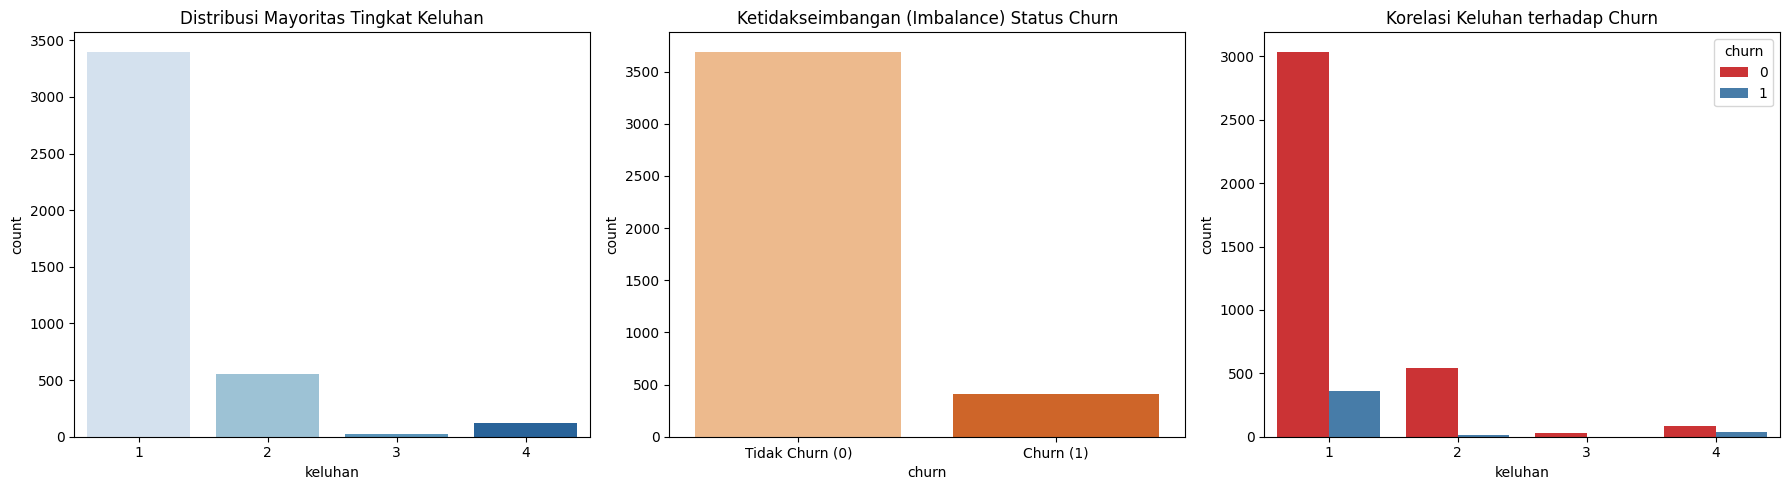

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_model, x='keluhan', palette='Blues', ax=axes[0])
axes[0].set_title('Distribusi Mayoritas Tingkat Keluhan')

sns.countplot(data=df_model, x='churn', palette='Oranges', ax=axes[1])
axes[1].set_title('Ketidakseimbangan (Imbalance) Status Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'])

sns.countplot(data=df_model, x='keluhan', hue='churn', palette='Set1', ax=axes[2])
axes[2].set_title('Korelasi Keluhan terhadap Churn')
plt.tight_layout()
plt.show()

## **5. MODELING: PERANCANGAN ALGORITMA DECISION TREE**

In [13]:
# Splitting Data Uji & Latih dengan distribusi seimbang per label (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model Instansiasi 
clf_dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Proses Latih (Fit)
clf_dt.fit(X_train, y_train)

# Hasil Prediksi
y_pred = clf_dt.predict(X_test)

## **6. EVALUASI DAN AKURASI (ROC-AUC)**


============= METRIK EVALUASI UTAMA =============
Accuracy   : 0.9061
Precision  : 0.5926
Recall     : 0.1951
F1-score   : 0.2936

Classification Report Lanjutan:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       738
           1       0.59      0.20      0.29        82

    accuracy                           0.91       820
   macro avg       0.75      0.59      0.62       820
weighted avg       0.88      0.91      0.88       820



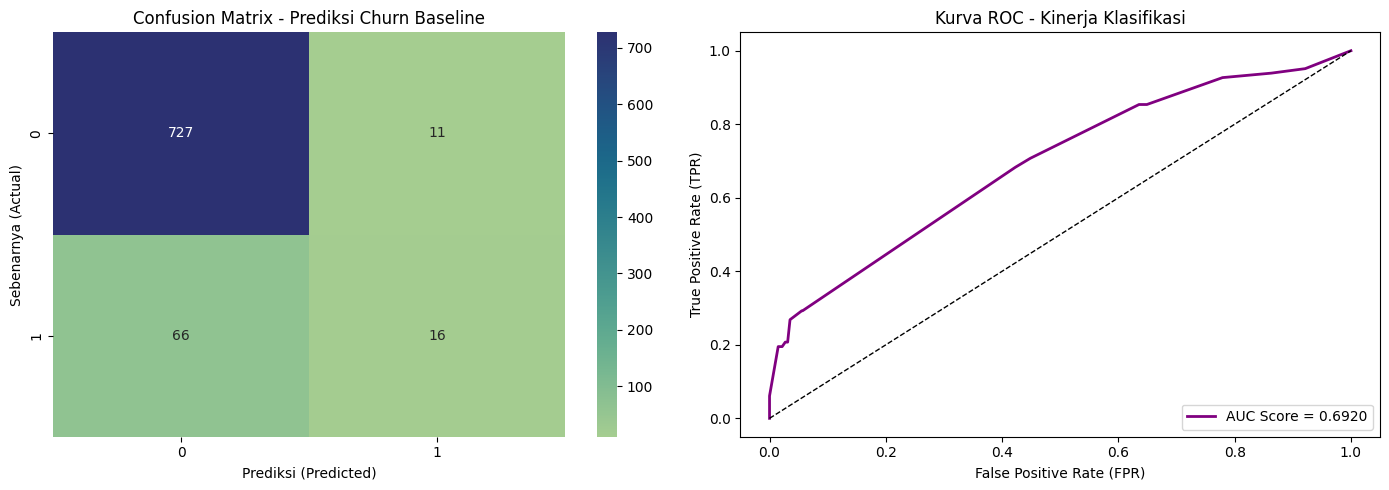

In [14]:
print('============= METRIK EVALUASI UTAMA =============')
print('Accuracy   : {:.4f}'.format(accuracy_score(y_test, y_pred)))
print('Precision  : {:.4f}'.format(precision_score(y_test, y_pred, zero_division=0)))
print('Recall     : {:.4f}'.format(recall_score(y_test, y_pred, zero_division=0)))
print('F1-score   : {:.4f}'.format(f1_score(y_test, y_pred, zero_division=0)))
print('\nClassification Report Lanjutan:')
print(classification_report(y_test, y_pred, zero_division=0))

# ---- Visualisasi Evaluasi (Confusion Matrix & ROC) ---- #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='crest', ax=axes[0])
axes[0].set_title('Confusion Matrix - Prediksi Churn Baseline')
axes[0].set_xlabel('Prediksi (Predicted)')
axes[0].set_ylabel('Sebenarnya (Actual)')

y_score = clf_dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

axes[1].plot(fpr, tpr, label=f'AUC Score = {auc_score:.4f}', color='purple', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Kurva ROC - Kinerja Klasifikasi')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## **7. INTERPRETASI POIN POHON KEPUTUSAN DAN IMPORTANCE**


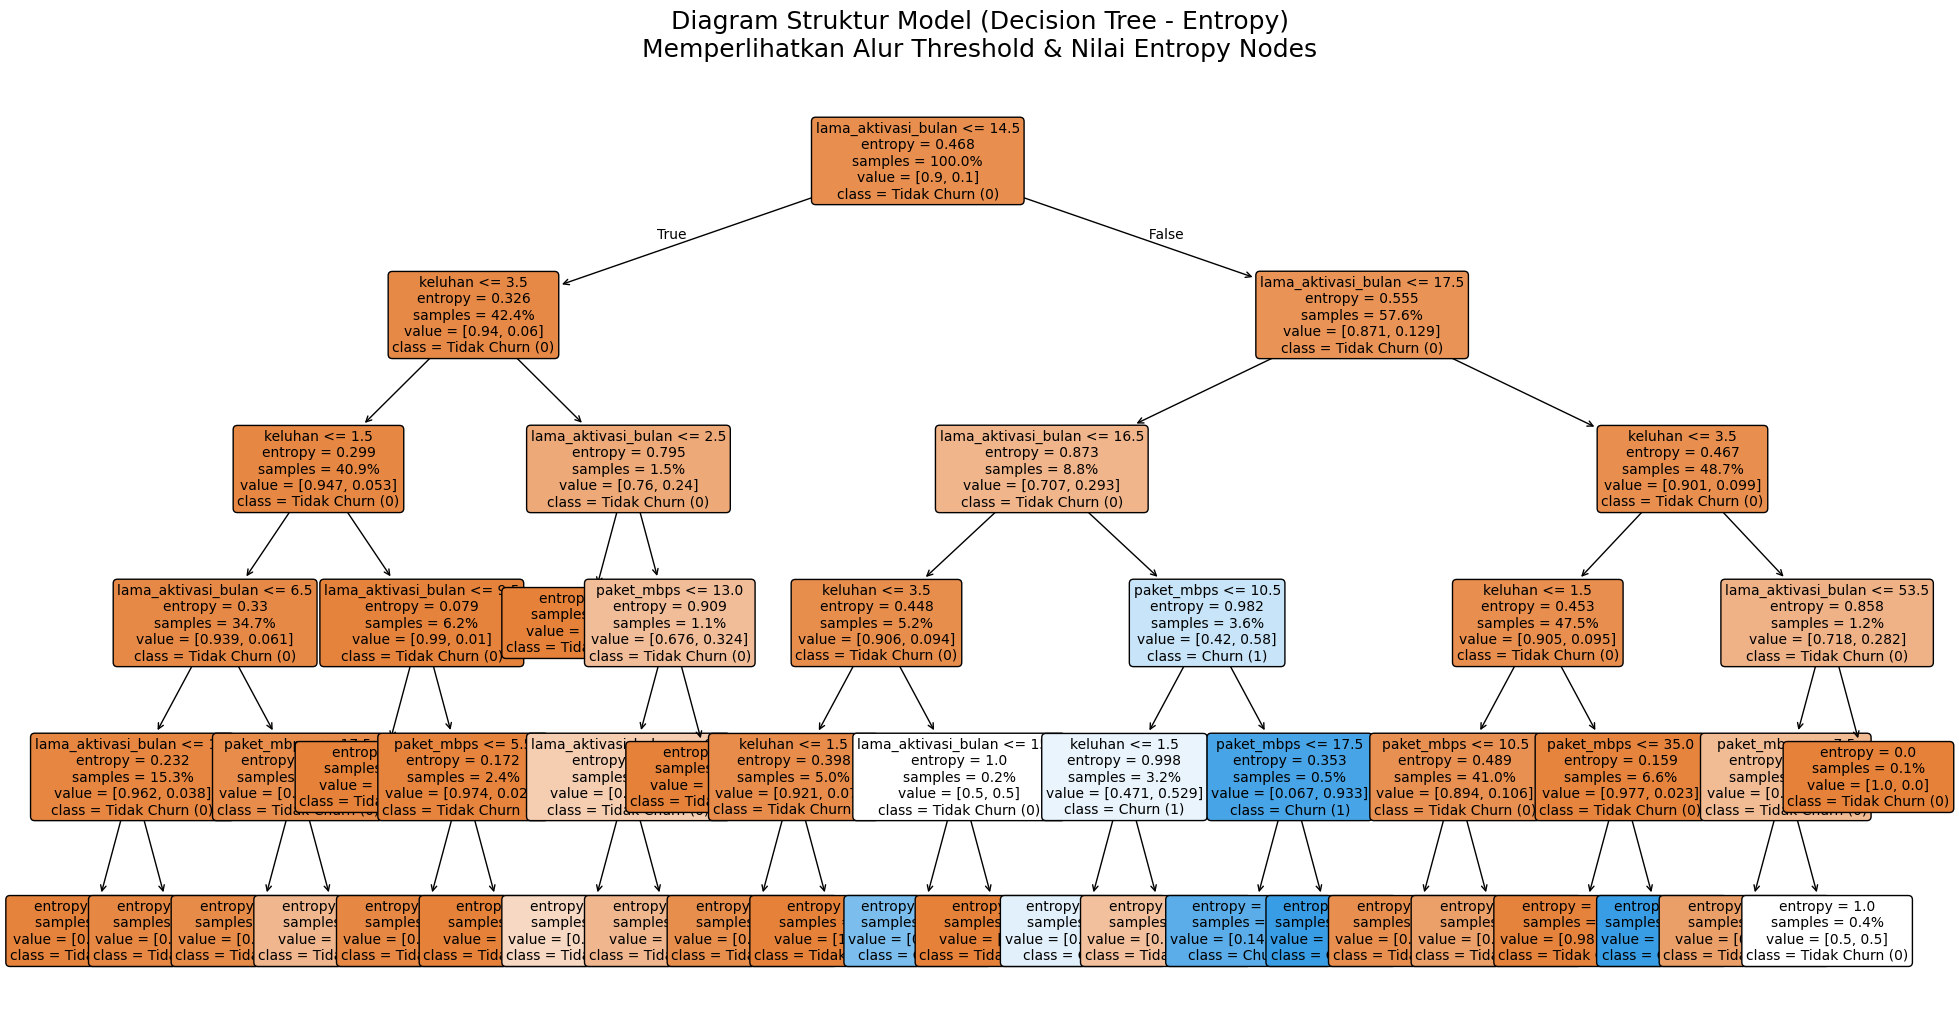

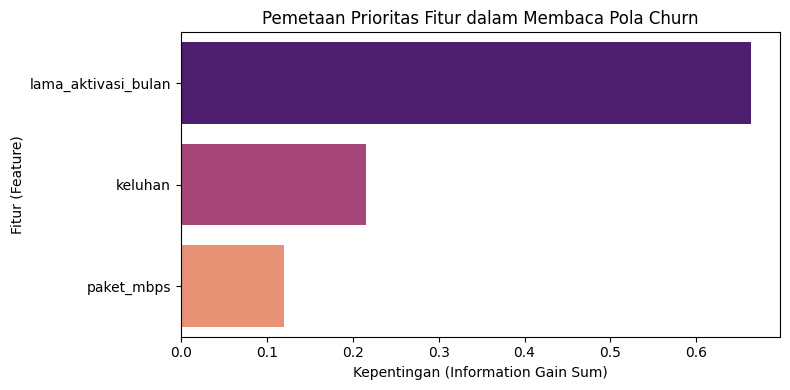

In [15]:
# 1. Plot Diagram Pohon Keputusan
plt.figure(figsize=(24, 12))  # Kanvas lebar untuk mengamati Tree
plot_tree(
    clf_dt,
    feature_names=feature_cols,
    class_names=['Tidak Churn (0)', 'Churn (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)
plt.title('Diagram Struktur Model (Decision Tree - Entropy)\nMemperlihatkan Alur Threshold & Nilai Entropy Nodes', fontsize=18, pad=20)
plt.show()

# 2. Plot Feature Importance
feat_imp = pd.DataFrame({
    'Fitur (Feature)': feature_cols,
    'Kepentingan (Information Gain Sum)': clf_dt.feature_importances_
}).sort_values(by='Kepentingan (Information Gain Sum)', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_imp, y='Fitur (Feature)', x='Kepentingan (Information Gain Sum)', palette='magma')
plt.title('Pemetaan Prioritas Fitur dalam Membaca Pola Churn')
plt.tight_layout()
plt.show()

## **8. EKSPOR HASIL PREDIKSI KESELURUHAN (OUTPUT)**

In [16]:
# Menghitung tebakan model pada seluruh dataset awal (X target)
df_model['predicted_churn_baseline'] = clf_dt.predict(X)

# Lokasi pengarsipan CSV
os.makedirs('../output', exist_ok=True)
export_path = '../output/data_churn_baseline_skripsi.csv'
df_model.to_csv(export_path, index=False)

print(f'Proses Selesai! Detail ekspor tersimpan di: {export_path}')
display(df_model[['kode_user', 'keluhan', 'churn', 'predicted_churn_baseline']].head())

Proses Selesai! Detail ekspor tersimpan di: ../output/data_churn_baseline_skripsi.csv


,kode_user,keluhan,churn,predicted_churn_baseline
0,GI0042,1,0,0
1,GI0035,1,0,0
2,GI0046,1,0,0
3,GI0047,1,1,0
4,GJ0071,2,0,0
